# Manifest explorer

The generator does not write audio. It writes a **manifest**: one CSV row per trial, holding every random choice that trial needs - which speakers, which recordings, when each one starts talking, how loud, which room, which noise clip. A renderer reads a row and produces exactly one mixture from it.

This notebook reads a manifest and explains what is in it, one theme at a time, so the recipe is understood before any audio exists.

Point `SPLIT` at any manifest in `data/manifests/` and re-run. Nothing below is specific to one split.

In [136]:
from pathlib import Path
from types import SimpleNamespace
import hashlib
import math
import numpy as np
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

In [94]:
RANGES = {"mixture_length_s": "mixture_length_s", "overlap_requested": "overlap_ratio",
        "sir_db": "sir_db", "snr_db": "snr_db",
        "target_loudness_lufs": "target_loudness_lufs", "t60_s": "t60_s",
        "room_l": "room_length_m", "room_w": "room_width_m",
        "room_h": "room_height_m", "mic_z": "mic_height_m",
        "target_z": "source_height_m", "interferer_z": "source_height_m"}

## 0. Setup

Loads four things for the chosen split:

| | |
|---|---|
| **manifest** | `data/manifests/<split>.csv` — the trials |
| **meta** | `<split>.meta.yaml` — when it was built, from which commit and seed |
| **generator settings** | the `defaults` + this split's overrides from the config, so we can check the manifest against the ranges it was told to sample |
| **indexes** | `data/index/` — every LibriSpeech utterance (speaker, duration, transcript) and every noise clip. The manifest stores only IDs, so durations and text are looked up here |

In [95]:
# Which manifest to analyse. Works for smoke_train, smoke_val, train, val,
# eval_public, eval_private, or a scratch manifest via MANIFEST_PATH.

SPLIT = "train"
MANIFEST_PATH = None      # full path to a .csv; overrides SPLIT when set

In [96]:

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 100)

# The generator packs multi-value fields as "a|b|c". These become real lists.
LIST_COLS = {
    "target_utts": "target_utt_list",
    "target_onsets_s": "target_onset_list",
    "interferer_utts": "interferer_utt_list",
    "interferer_onsets_s": "interferer_onset_list",
}

# Columns pandas must NOT type-infer.
#   IDs: "0090" would become the int 90 and stop matching the folder on disk.
#   Packed fields: if no row in a manifest happens to contain a "|", the column
#   looks numeric and is read as float64 -- then the parse below sees a float
#   instead of a string and yields [] for every row, silently dropping every
#   onset. Content-dependent dtypes break when the content changes.
STR_COLS = {c: str for c in [
    "target_speaker", "interferer_speaker", "target_chapter", "interferer_chapter",
    *LIST_COLS,
]}


def find_root(start=None):
    """Walk up until CLAUDE.md appears, so paths resolve whether the kernel
    started in src/exploratory/ or at the repo root."""
    here = (start or Path.cwd()).resolve()
    for d in [here, *here.parents]:
        if (d / "CLAUDE.md").exists():
            return d
    raise RuntimeError(f"repo root not found above {here}")


ROOT = find_root()


def _as_list(cell):
    """"a|b" -> ["a", "b"]. Empty or missing -> []. Target-absent trials
    genuinely have no target utterances, so [] is a real value, not a bug."""
    if not isinstance(cell, str) or not cell.strip():
        return []
    return cell.split("|")


def load(split, manifest_path=None):
    """Everything needed to analyse one split, bundled together."""
    man = Path(manifest_path) if manifest_path else ROOT / "data/manifests" / f"{split}.csv"
    df = pd.read_csv(man, dtype=STR_COLS)
    columns = list(df.columns)

    for raw, parsed in LIST_COLS.items():
        vals = df[raw].map(_as_list)
        df[parsed] = vals if raw.endswith("_utts") else vals.map(
            lambda v: [float(x) for x in v])
        # A populated field that parsed to nothing means the parse is broken,
        # not that the trial is empty. Fail loudly rather than analyse zeros.
        broke = df[raw].notna() & (df[parsed].str.len() == 0)
        assert not broke.any(), f"{raw}: {int(broke.sum())} rows failed to parse"

    # One onset per utterance, or the two lists cannot be zipped meaningfully.
    for who in ("target", "interferer"):
        assert (df[f"{who}_utt_list"].str.len()
                == df[f"{who}_onset_list"].str.len()).all(), f"{who}: length mismatch"

    meta = yaml.safe_load(man.with_suffix(".meta.yaml").read_text())

    cfg_file = ROOT / meta["config"]
    config = yaml.safe_load(cfg_file.read_text())
    cfg = {**config["defaults"], **config["splits"].get(split, {})}
    cfg["seed"], cfg["sample_rate"] = config["seed"], config["sample_rate"]
    # If the config changed after the manifest was written, the ranges we check
    # against are not the ranges that were actually sampled from.
    stale = hashlib.md5(cfg_file.read_bytes()).hexdigest() != meta.get("config_md5")

    idx = ROOT / "data/index"
    utt_file = idx / f"utterances_{split}.csv"
    utts = (pd.read_csv(utt_file, dtype={"speaker": str, "chapter": str}).set_index("utt")
            if utt_file.exists() else None)
    noise_file = idx / f"noise_{cfg['noise_split']}.csv"
    noise = pd.read_csv(noise_file).set_index("clip") if noise_file.exists() else None

    # Onsets alone do not say when a speaker stops. Attach each chosen
    # utterance's length so talking intervals can be reconstructed.
    if utts is not None:
        dur = utts["duration"].to_dict()
        for who in ("target", "interferer"):
            df[f"{who}_dur_list"] = df[f"{who}_utt_list"].map(
                lambda us: [dur[u] for u in us])

    return SimpleNamespace(split=split, path=man, df=df, columns=columns,
                           meta=meta, cfg=cfg, utts=utts, noise=noise,
                           config_stale=stale)


def spans(row, who):
    """When `who` is actually talking, as [(start_s, end_s), ...]."""
    return [(o, o + d) for o, d in
            zip(row[f"{who}_onset_list"], row[f"{who}_dur_list"])]


def text_of(D, row, who):
    """The words spoken by `who` in this trial, in order."""
    return " ".join(D.utts.loc[u, "text"] for u in row[f"{who}_utt_list"])

In [97]:
D = load(SPLIT, MANIFEST_PATH)

print(f"{D.path.relative_to(ROOT)}")
print(f"  {len(D.df)} trials, {len(D.columns)} columns")
print(f"  built {D.meta['generated']}  seed {D.meta['seed']}  "
      f"commit {D.meta['git_commit'][:7]}  unsatisfiable {D.meta['n_failed']}")
print(f"  generator {D.meta['config']}"
      + ("   ** CHANGED since build — ranges below may not match **"
         if D.config_stale else "   (unchanged since build)"))
print(f"  utterance index  {'loaded' if D.utts is not None else 'MISSING'}"
      f"   ({len(D.utts)} utterances)" if D.utts is not None else "")
print(f"  noise index      {'loaded' if D.noise is not None else 'MISSING'}"
      f"   ({len(D.noise)} clips, WHAM! split '{D.cfg['noise_split']}')"
      if D.noise is not None else "")

data/manifests/train.csv
  19569 trials, 41 columns
  built 2026-08-11  seed 42  commit 139b227  unsatisfiable 431
  generator experiments/configs/generator.yaml   (unchanged since build)
  utterance index  loaded   (132553 utterances)
  noise index      loaded   (20000 clips, WHAM! split 'tr')


## 1. What each row does

### 1.1  `trial_id`

Each trial generated by the manifest can be replaced/regenerated. Secondly, since the manifest made use of `blake2b` instead of `hash()`, we are guaranteed to get identical data between different authors/users of the repository. Note that the 6 digit number at the end of the `trial_id` is NOT the row number, it is 

In [98]:
D.df.head(10)

,trial_id,split,target_speaker,target_chapter,target_utts,target_onsets_s,target_speech_s,target_activity,interferer_speaker,interferer_chapter,interferer_utts,interferer_onsets_s,interferer_speech_s,interferer_activity,enrollment_utt,enrollment_offset_s,enrollment_length_s,enrollment_eq,noise_clip,noise_offset_s,mixture_length_s,sir_db,snr_db,target_loudness_lufs,overlap_requested,overlap_achieved,t60_s,room_l,room_w,room_h,mic_x,mic_y,mic_z,target_x,target_y,target_z,interferer_x,interferer_y,interferer_z,target_absent,same_gender,target_utt_list,target_onset_list,interferer_utt_list,interferer_onset_list,target_dur_list,interferer_dur_list
0,train-42-000000,train,4014,NaN,NaN,NaN,0.000,0.0000,781,127518,781-127518-0024,1.6255,7.910,0.4521,4014-186179-0023,5.8253,5.0,0,02da010b_0.85031_01da010s_-0.85031.flac,8.0788,17.495,NaN,8.75,-30.29,0.0000,0.0000,0.3280,8.644,8.297,3.801,3.396,5.230,0.985,3.234,4.381,1.036,2.807,6.083,1.458,1,1,[],[],[781-127518-0024],[1.6255],[],[7.91]
1,train-42-000001,train,1737,NaN,NaN,NaN,0.000,0.0000,5157,47237,5157-47237-0039,4.0964,9.410,0.5709,1737-142397-0001,6.9285,5.0,1,023a010t_1.557_01nc0216_-1.557.flac,0.9359,16.481,NaN,14.59,-28.08,0.0000,0.0000,0.5471,6.338,6.095,3.481,3.746,2.932,1.404,5.151,3.811,1.232,3.453,4.799,1.253,1,0,[],[],[5157-47237-0039],[4.0964],[],[9.41]
2,train-42-000002,train,6553,82558,6553-82558-0040|6553-82558-0041,1.2662|10.5818,16.110,0.8481,6078,54013,6078-54013-0028,0.3800,14.105,0.7425,6553-86683-0041,4.9427,5.0,1,01po030l_0.91212_01jo0302_-0.91212.flac,0.0944,18.996,-0.51,19.50,-25.11,0.6359,0.6361,0.5204,9.446,5.878,3.841,5.890,3.193,1.639,4.770,3.295,1.607,6.652,1.713,1.505,0,0,"[6553-82558-0040, 6553-82558-0041]","[1.2662, 10.5818]",[6078-54013-0028],[0.38],"[8.18, 7.93]",[14.105]
3,train-42-000003,train,3328,168638,3328-168638-0021|3328-168638-0022,0.3186|14.3250,15.710,0.8285,7594,91192,7594-91192-0013,7.3713,6.285,0.3314,3328-166436-0000,2.7825,5.0,1,20ga010f_1.6844_01za010j_-1.6844.flac,4.2906,18.962,-4.47,9.17,-26.72,0.2219,0.2224,0.4508,8.873,6.797,3.670,3.252,4.389,1.444,1.772,5.239,0.952,4.122,5.431,1.693,0,0,"[3328-168638-0021, 3328-168638-0022]","[0.3186, 14.325]",[7594-91192-0013],[7.3713],"[11.27, 4.44]",[6.285]
4,train-42-000004,train,1390,NaN,NaN,NaN,0.000,0.0000,332,128985,332-128985-0003,6.5001,8.160,0.4682,1390-130493-0008,6.8375,5.0,1,029o0306_0.60504_01pc021e_-0.60504.flac,0.6812,17.427,NaN,0.38,-31.14,0.0000,0.0000,0.2544,8.276,5.275,3.222,5.274,3.421,1.595,6.186,2.824,1.799,5.152,2.667,0.919,1,0,[],[],[332-128985-0003],[6.5001],[],[8.16]
5,train-42-000005,train,8066,290047,8066-290047-0031,0.8667,16.245,0.8280,7959,109176,7959-109176-0034,5.4970,13.770,0.7019,8066-114256-0007,0.0207,5.0,0,40io0313_1.7759_40lc020w_-1.7759.flac,11.9125,19.619,-3.43,14.56,-27.65,0.5922,0.5920,0.1954,7.678,5.580,3.624,4.129,2.726,1.398,4.137,3.585,1.051,4.659,2.324,1.351,0,0,[8066-290047-0031],[0.8667],[7959-109176-0034],[5.497],[16.245],[13.77]
6,train-42-000006,train,6215,NaN,NaN,NaN,0.000,0.0000,322,124146,322-124146-0022|322-124146-0023|322-124146-0024,1.1664|3.8664|7.4264,13.250,0.7600,6215-68888-0026,5.8990,5.0,1,016o030y_0.80072_409a0111_-0.80072.flac,6.7390,17.435,NaN,11.88,-29.69,0.0000,0.0000,0.5524,8.635,5.237,3.340,5.131,2.170,0.960,6.616,3.143,1.163,4.555,2.878,1.305,1,1,[],[],"[322-124146-0022, 322-124146-0023, 322-124146-...","[1.1664, 3.8664, 7.4264]",[],"[2.7, 3.56, 6.99]"
7,train-42-000007,train,2751,NaN,NaN,NaN,0.000,0.0000,8580,287363,8580-287363-0018,2.6040,11.075,0.6512,2751-142363-0006,5.1347,5.0,0,40ha0102_1.5825_406o0309_-1.5825.flac,4.9337,17.006,NaN,4.89,-26.17,0.0000,0.0000,0.4326,8.334,6.545,3.765,3.168,4.001,1.789,4.458,4.990,1.627,1.652,4.644,1.297,1,0,[],[],[8580-287363-0018],[2.604],[],[11.075]
8,train-42-000008,train,8791,NaN,NaN,NaN,0.000,0.0000,948,132705,948-132705-0011,2.3306,10.540,0.5545,8791-291101-0104,7.2731,5.0,1,01ca0103_1.881_207c010i_-1.881.flac,3.8031,19.007,NaN,3.94,-27.45,0.0000,0.0000,0.2361,5.300,7.676,3.041

In [99]:
print(f"  target speaker IDs: {D.df['target_speaker'].nunique()} "
      f"({D.df['target_speaker'].unique()})")

  target speaker IDs: 1170 (<StringArray>
['4014', '1737', '6553', '3328', '1390', '8066', '6215', '2751', '8791', '1001',
 ...
 '1958', '3180', '7178',  '708', '7128',  '831', '3551', '8190', '7416',  '501']
Length: 1170, dtype: str)


In [100]:
D.df.columns
print(f"Num columns: {len(D.columns)}")

Num columns: 41


Number of samples: 19569


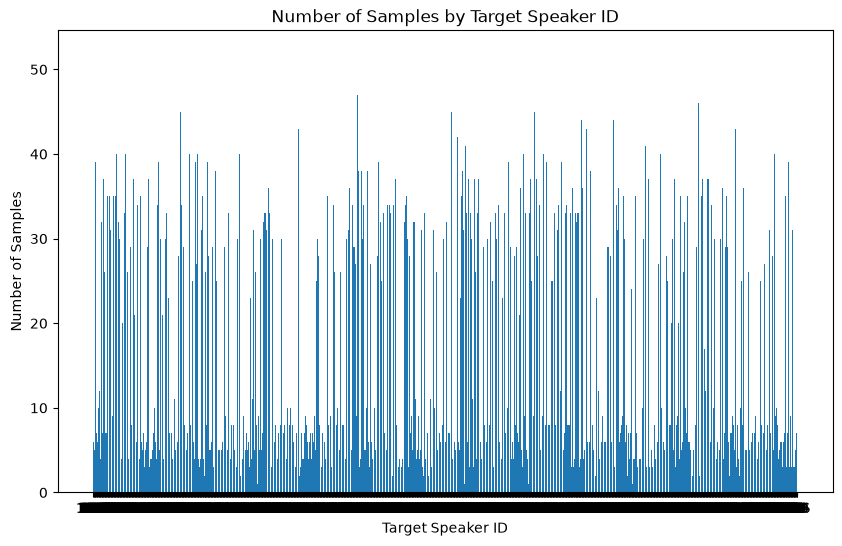

In [101]:
print(f"Number of samples: {len(D.df)}")
number_by_target_speaker = D.df.groupby('target_speaker').size().to_dict()
plt.figure(figsize=(10, 6))
plt.bar(number_by_target_speaker.keys(), number_by_target_speaker.values())
plt.xlabel('Target Speaker ID')
plt.ylabel('Number of Samples')
plt.title('Number of Samples by Target Speaker ID')
plt.show()

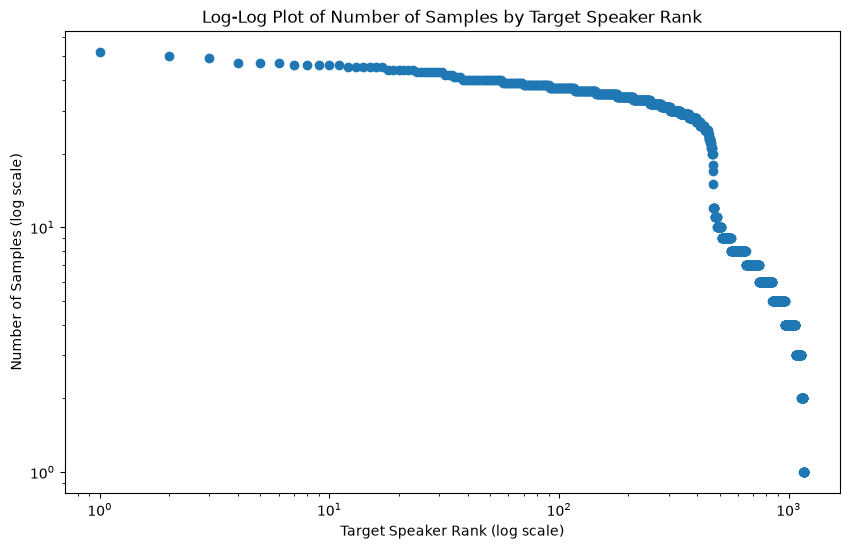

In [102]:
# log log plot of distribution of number of samples for target speaker rank
sorted_counts = sorted(number_by_target_speaker.items(), key=lambda x: x[1], reverse=True)
ranks = range(1, len(sorted_counts) + 1)
counts = [v for k, v in sorted_counts]
plt.figure(figsize=(10, 6))
plt.loglog(ranks, counts, marker='o', linestyle='None')
plt.xlabel('Target Speaker Rank (log scale)')
plt.ylabel('Number of Samples (log scale)')
plt.title('Log-Log Plot of Number of Samples by Target Speaker Rank')
plt.show()

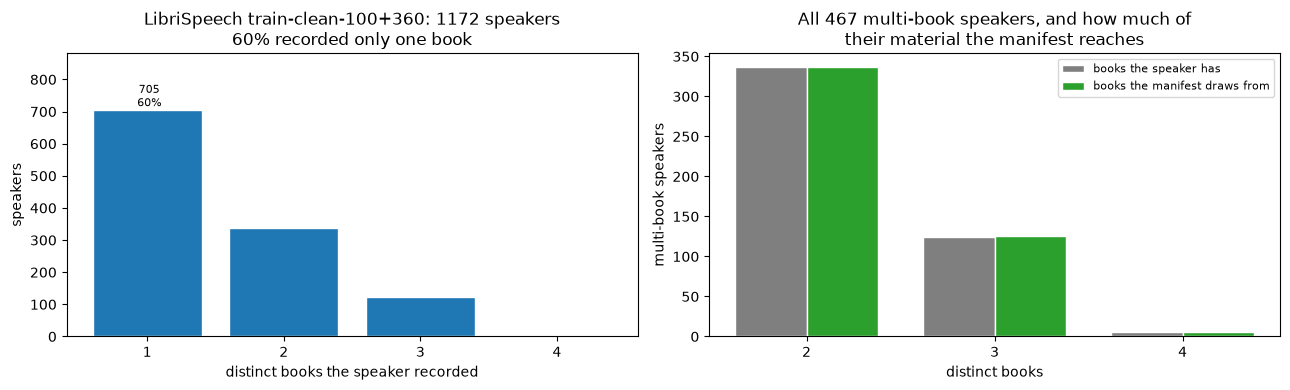

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

one book only  705/1172 (60.2%)
books used, mean 2.29 of 2.29 available


In [133]:
# check the book assignment for each speaker. The manifest should not draw from all books a speaker recorded, but only a subset of them. This is important for the target speaker extraction task, as it ensures that the model is tested on unseen books for each speaker.
# LibriSpeech ships one row per chapter: chapter | speaker | minutes | subset |  ... | book
present = D.df[D.df["target_absent"] == 0]
ch = []
for line in (ROOT / "data/librispeech/LibriSpeech/CHAPTERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    ch.append({"chapter": f[0], "speaker": f[1], "subset": f[3], "book": f[5]})
    
ch = pd.DataFrame(ch)

# only the subsets our splits were drawn from
ours = ch[ch["subset"].isin(["train-clean-100", "train-clean-360"])]
available = ours.groupby("speaker")["book"].nunique()

# how many books a speaker actually gets used for, as the mixture source.
# enrollment is excluded: B8 guarantees it is a different book, so counting it
# would add exactly 1 to every speaker and hide the real spread.
used = present.groupby("target_speaker")["target_chapter"].apply(
lambda c: c.map(dict(zip(ch["chapter"], ch["book"]))).nunique())

multi = available[available > 1].index
used_multi = used[used.index.isin(multi)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

counts = available.value_counts().sort_index()
ax1.bar(counts.index, counts.values, color="tab:blue", edgecolor="white")
for x, v in counts.items():
    ax1.text(x, v, f" {v}\n {v/len(available):.0%}", ha="center", va="bottom",
    fontsize=8)
    ax1.set_xlabel("distinct books the speaker recorded")
    ax1.set_ylabel("speakers")
    ax1.set_xticks(counts.index)
    ax1.set_ylim(0, counts.max() * 1.25)
    ax1.set_title(f"LibriSpeech train-clean-100+360: {len(available)} speakers\n"
            f"{(available == 1).mean():.0%} recorded only one book")

    avail_multi = available[multi]
    w = 0.38
    xs = sorted(set(avail_multi) | set(used_multi))
    ax2.bar([x - w/2 for x in xs], [(avail_multi == k).sum() for k in xs], w,
            color="tab:grey", edgecolor="white", label="books the speaker has")
    ax2.bar([x + w/2 for x in xs], [(used_multi == k).sum() for k in xs], w,
            color="tab:green", edgecolor="white", label="books the manifest draws from")
    ax2.set_xlabel("distinct books")
    ax2.set_ylabel("multi-book speakers")
    ax2.set_xticks(xs)
    ax2.set_title(f"All {len(multi)} multi-book speakers, and how much of\n"
                f"their material the manifest reaches")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

print(f"one book only  {(available==1).sum()}/{len(available)} "
    f"({(available==1).mean():.1%})")
print(f"books used, mean {used_multi.mean():.2f} of {avail_multi.mean():.2f} available")


## 2. Timing and overlap
### 2.1 `mixture_length_s`, `target_onset_s`, `interferer_onset_s`, `target_speech_s`, `target_activity`, `interferer_speech_s`, `interferer_activity`, `overlap_requested`, `overlap_achieved`

These columns are created using the following parameters to determine where the target will be speaking, for how long they will be speaking, where the interferer will speak, for how long will there be overlap between interefer and target:

- $\texttt{target\_activity\_ratio}: 0.75$ which is the goal for how long the target should ideally be speaking in the sample. This is the value that the paper $\textit{`REAL-TSE'}$ aimed for.
- $\texttt{activity\_tolerance}: 0.1$ how far above the goal the generator is allowed to land. Speech is built from WHOLE utterances, so there will be cases where we have longer speech so we have a range from 0.75-0.85 as a window. We will never consider lower.
- $\texttt{overlap\_ratio}: [0.2, 0.7]$ is drawn uniformly and represents the fraction of the window where both people are talking.
- $\texttt{overlap\_tolerance}: 0.03$ used for the interferer which is slid along the window to hit the requested overlap. 
- $\texttt{max\_utterances\_per\_source}: 8$ is the max number of consecutive utterances to make one speaker's speech, sp a source is never assembled from a long string of tiny fragments.

Therefore all of these columns are not independant draws and constrain each other arithmetically.


A big note, we only use one block to interfere with the target and not many places of interference. This does help simplify the train task, however, it does cost us realism. The hope is that these individual instances will translate to the many times we call on the model.

In [103]:
# only consider trials with a target speaker. Absent target trials have overlap 0 by definition
present = D.df[D.df['target_absent'] == 0]
print(f"Percentage of trials with a target speaker: {len(present)/len(D.df)*100:.2f}%")

Percentage of trials with a target speaker: 64.56%


#### Structural asymmetry

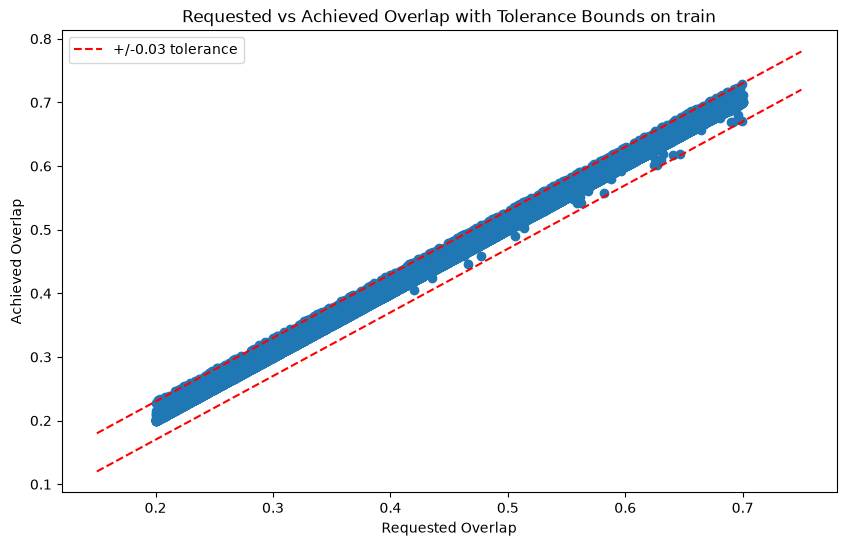

In [104]:
tolerance = D.cfg["overlap_tolerance"]
line = [0.15, 0.75]

plt.figure(figsize=(10, 6))
plt.scatter(present['overlap_requested'], present['overlap_achieved'])
plt.plot(line, [v + tolerance for v in line], color='red', linestyle='--', label=f'+/-{tolerance} tolerance')
plt.plot(line, [v - tolerance for v in line], color='red', linestyle='--')
plt.xlabel('Requested Overlap')
plt.ylabel('Achieved Overlap')
plt.title(f'Requested vs Achieved Overlap with Tolerance Bounds on {D.split}')
plt.legend()
plt.show()

In [105]:
miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
print(f"Worst miss: {miss.max():.4f}, Mean miss: {miss.mean():.4f}, Median miss: {miss.median():.4f}")
print(f"Acceptable hit percentages: {((miss <= tolerance).sum() / len(miss)) * 100:.2f}%")
print(f"Exact hit percentages: {((miss <= 1e-9).sum() / len(miss)) * 100:.2f}%")

Worst miss: 0.0300, Mean miss: 0.0040, Median miss: 0.0003
Acceptable hit percentages: 99.98%
Exact hit percentages: 8.76%


#### Activity, overlap and speech time

In [106]:
# activity 
difference = (present["target_activity"] - present["target_speech_s"]/ present["mixture_length_s"]).abs()
print(f"Worst activity difference: {difference.max():.4f}, Mean activity difference: {difference.mean():.4f}, Median activity difference: {difference.median():.4f}") 

Worst activity difference: 0.0001, Mean activity difference: 0.0000, Median activity difference: 0.0000


In [107]:
# speech time is sum of utterance durations
speech_time_diff = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
print(f"Worst speech time difference: {speech_time_diff.max():.4f}, Mean speech time difference: {speech_time_diff.mean():.4f}, Median speech time difference: {speech_time_diff.median():.4f}")  

Worst speech time difference: 0.0000, Mean speech time difference: 0.0000, Median speech time difference: 0.0000


In [108]:
# overlap is the shared time between two speaker talking intervals
worst = 0.0
for i, row in present.iterrows():
    shared_time = 0.0
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            shared_time += max(0, min(t_end, i_end) - max(t_start, i_start))
    worst = max(worst, abs(shared_time / row["mixture_length_s"] - row["overlap_achieved"]))
print(f"Worst overlap difference: {worst:.4f}")

Worst overlap difference: 0.0001


Make a timeline plot for the first 3 trials with a target speaker, showing the target and interferer utterances as horizontal bars.

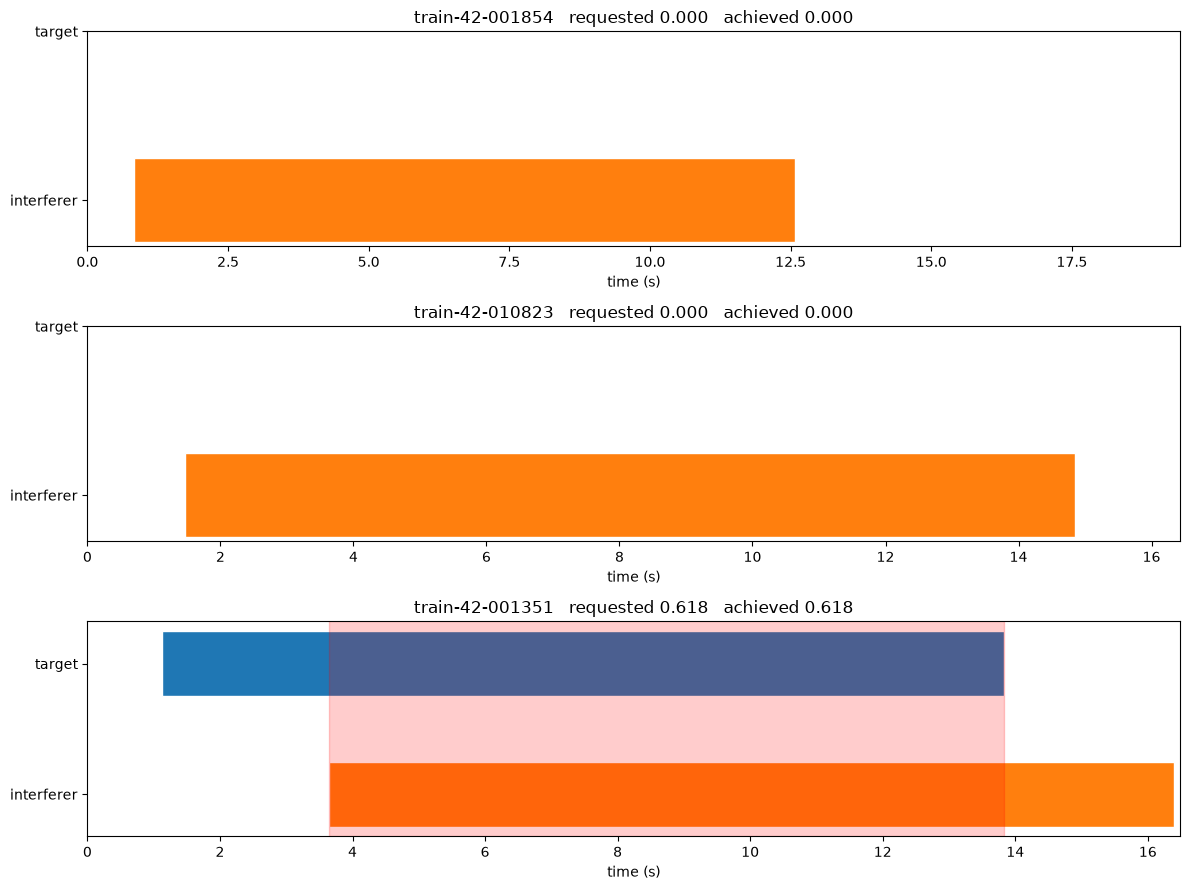

In [109]:
rows = 3
random_indices = np.random.choice(D.df.index, size=rows, replace=False)

fig, axes = plt.subplots(rows, 1, figsize=(12, 3 * rows))
if rows == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    random_index = random_indices[i]
    row = D.df.iloc[random_index]

    # target bars on the top row, interferer underneath.
    # white edges so back-to-back utterances stay visible as separate blocks.
    for start, end in spans(row, "target"):
        ax.barh(1, end - start, left=start, height=0.5,
                color="tab:blue", edgecolor="white")
    for start, end in spans(row, "interferer"):
        ax.barh(0, end - start, left=start, height=0.5,
                color="tab:orange", edgecolor="white")

    # shade every stretch where both are talking
    for t_start, t_end in spans(row, "target"):
        for i_start, i_end in spans(row, "interferer"):
            lo, hi = max(t_start, i_start), min(t_end, i_end)
            if hi > lo:
                ax.axvspan(lo, hi, color="red", alpha=0.2)

    ax.set_xlim(0, row["mixture_length_s"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["interferer", "target"])
    
    # Only label x-axis on the bottom plot to reduce clutter, or keep on all
    ax.set_xlabel("time (s)")
    ax.set_title(f"{row['trial_id']}   requested {row['overlap_requested']:.3f}   "
                 f"achieved {row['overlap_achieved']:.3f}")

plt.tight_layout()
plt.show()


### 3. Levels

#### `sir_db`, `snr_db`, `target_loudness_lufs` 
where the most notable thing is that the signal to interference ratio is always 0 dB when the target is absent. These features are controlled by the following parameter:
- $\texttt{clip\_ceiling}: 0.95$ which is responsible for the loudness of the target in the audio clip and is measured using BS.1770 as a loudness measure. 

Remember, a rendered trial consists of three audio segments: the target speaker, the interferer speaker, and the background noise. Each of these segments are mixed together, but we cannot assume that they will always be at the same level. To simplify our task, we define the target speaker's loudness using the LUFS (Loudness Units relative to Full Scale) standard, which we use as an anchor for the other segments. The signal-to-interference ratio (SIR) places the interferer relative to the target, and the signal-to-noise ratio (SNR) places the background noise relative to the target. A simple deduction is that the higher the db of the target, the easier the task.

**NOTE:** SIR and SNR effect the downstream ASR task differently NEGATIVELY and thus are two separate issues. These errors have different kind of errors in the output TEXT: 
- SIR: The louder this is, the more frequently we can expect insertions and substitutions of real words.
- SNR: This will cause more deletions and garbling where we can expect non-words and deletions.

We should use the SI-SDR metric to account for these damages as one unit.

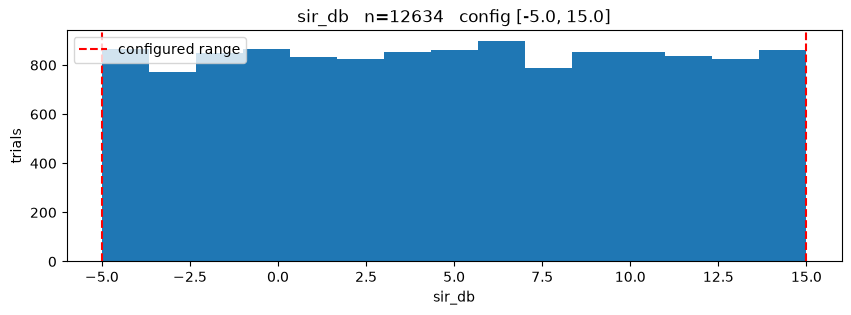

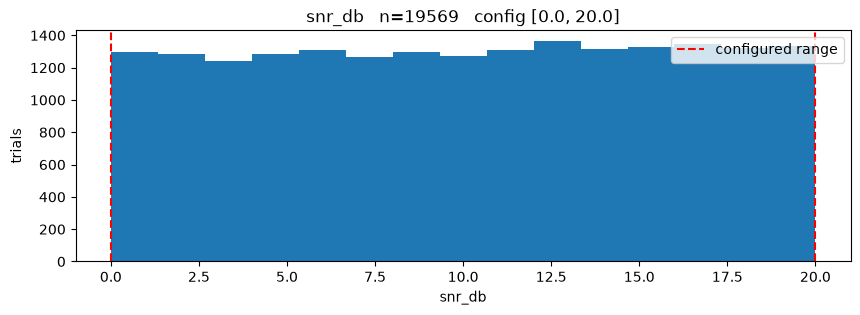

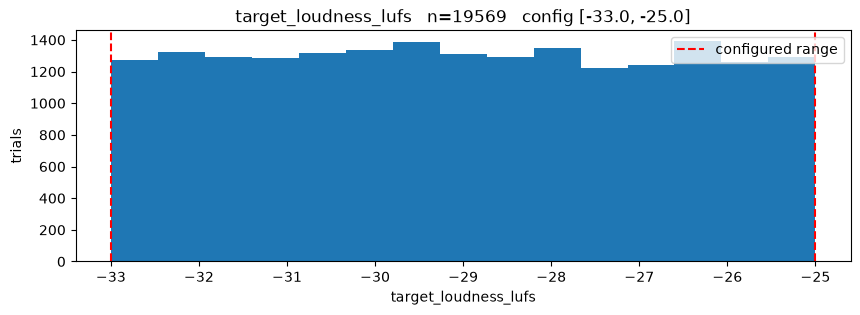

In [110]:
# does each level column cover the range the config asked for?
# no range= on the hist, so anything outside the configured range stays visible
for col in ["sir_db", "snr_db", "target_loudness_lufs"]:
    lo, hi = D.cfg[col]
    v = D.df[col].dropna()
    plt.figure(figsize=(10, 3))
    plt.hist(v, bins=15)
    plt.axvline(lo, color="red", linestyle="--")
    plt.axvline(hi, color="red", linestyle="--", label="configured range")
    plt.xlabel(col)
    plt.ylabel("trials")
    plt.title(f"{col}   n={len(v)}   config [{lo}, {hi}]")
    plt.legend()
    plt.show()


In [111]:
 # check independence
cols = ["sir_db", "snr_db", "target_loudness_lufs", "overlap_requested",
        "interferer_activity", "target_activity", "mixture_length_s", "t60_s"]
c = present[cols].corr()
floor = 2 / np.sqrt(len(present))

print(f"n = {len(present)}   noise floor |r| = {floor:.2f}")
print("pairs above the noise floor:")
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = c.iloc[i, j]
        if abs(r) > floor:
            print(f"   {cols[i]:22} {cols[j]:22} r = {r:+.2f}")


n = 12634   noise floor |r| = 0.02
pairs above the noise floor:
   overlap_requested      interferer_activity    r = +0.95
   interferer_activity    target_activity        r = -0.09
   target_activity        mixture_length_s       r = -0.17
   mixture_length_s       t60_s                  r = -0.03


The pairs that must never appear are sir_db, snr_db, overlap_* and t60_s against each other. Those four are your experimental axes. If any two of them correlate, then "WER degrades as SIR falls" becomes unprovable — you can't tell whether it was the SIR or the thing riding along with it.


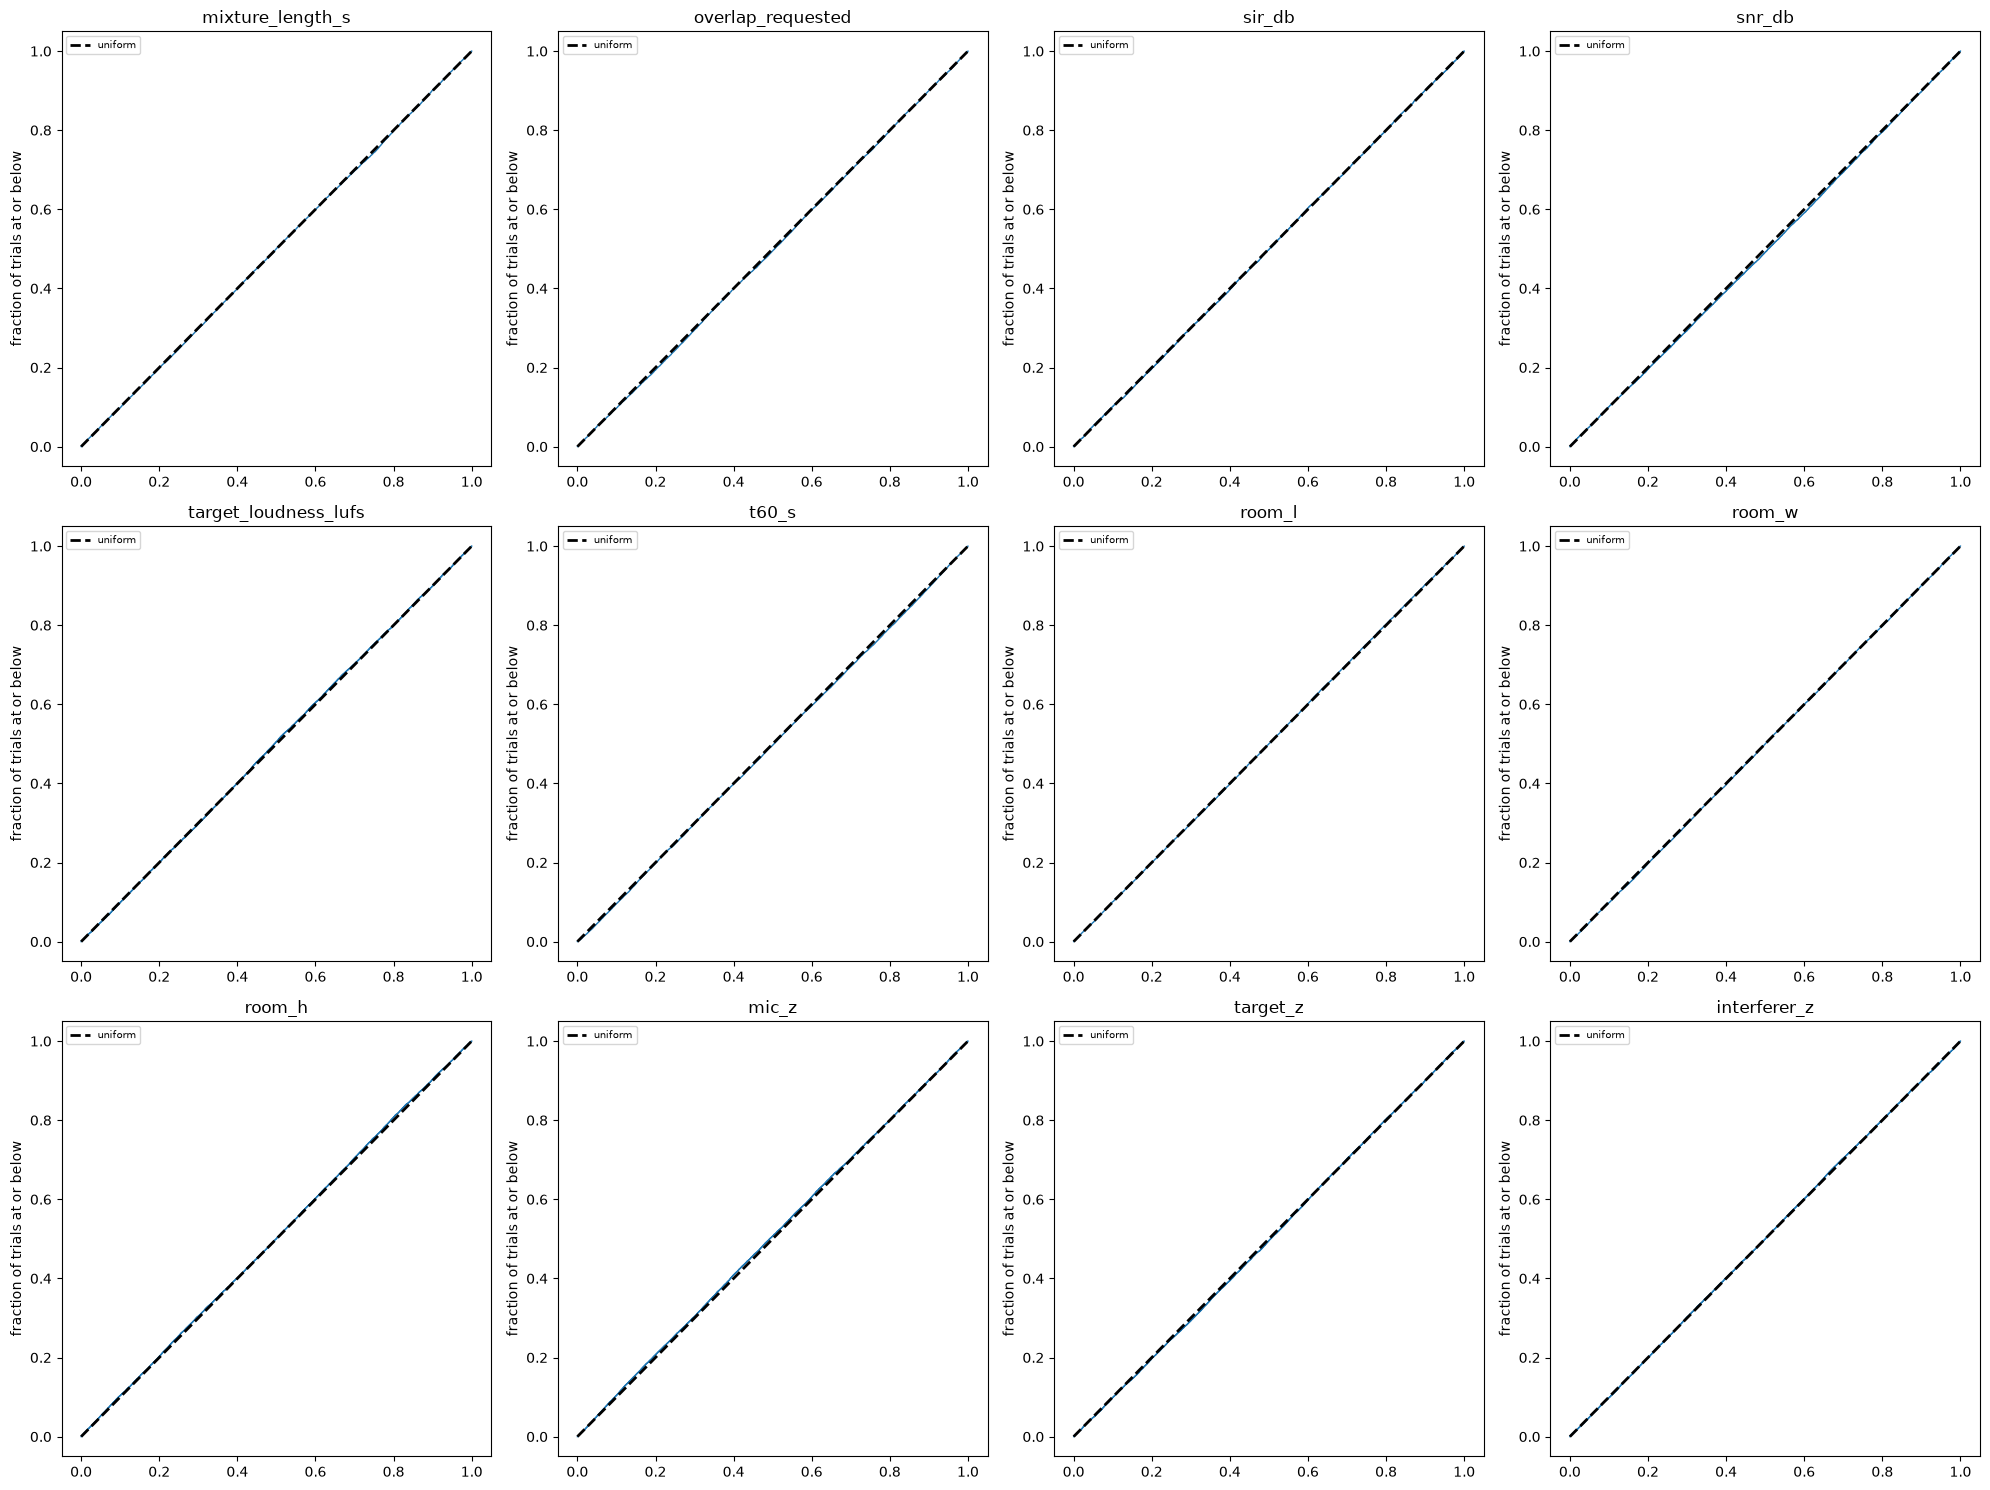

In [112]:
n = len(RANGES)
cols = min(n, 4)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = np.atleast_1d(axes).flatten()

for ax, (col, key) in zip(axes, RANGES.items()):
    lo, hi = D.cfg[key]
    v = D.df[col][D.df["target_absent"] == 0] if col == "overlap_requested" else D.df[col]
    v = np.sort(v.dropna())
    
    ax.plot((v - lo) / (hi - lo), np.arange(1, len(v) + 1) / len(v), linewidth=1)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2, label="uniform")
    
    ax.set_ylabel("fraction of trials at or below")
    
    # Column name instead of the generic title
    ax.set_title(col) 
    ax.legend(fontsize=7)

# Hide any empty subplots in the grid
for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### 4. Room and reverberation


4.1 There are 13 independent room features that contribute to this audio setup. These variables include:
- `t60_s` is the time it takes for a room's echoes to decay by 60dB which I sample from [0.15, 0.6].
- `room_l/w/h`
- `mic_x/y/z`
- `target_x/y/z`
- `interferer_x/y/z`

which describe a shoebox room which is built with the $\texttt{pyroomacoustics}$ library. We place the mic and two sources at the given coordinates, set wall absorbtion so that the delay time from doppler effect is the `t60_s` value, and generate one room impulse response per source. We also make reverb to make the audio sound like a room rather than a recording booth. The most important thing is that ALL SPEAKERS IN A SAMPLE MUST BE IN THE SAME ROOM!

The procedure per source:
1. Draw a horizontal distance from the mic — source_distance_m: [0.66, 2.0] m, uniform.
2. Draw an azimuth uniformly over the full circle, 0 to 2π.
3. Convert to x/y by trigonometry around the mic: x = mic_x + d·cos(az), y = mic_y + d·sin(az).
4. Reject and redraw if the point lands within 0.3 m of any wall — up to 50 attempts, then raise.
5. Draw z independently from source_height_m: [0.9, 1.8] m. This is a separate draw, not derived from the distance.

The mic itself is placed first, in sample_room (lines 146–148): x and y uniform over the central 35–65% of each room dimension, z
from mic_height_m: [0.9, 1.8]. So the mic is always roughly central and the sources orbit it.


Distribution of t60_s


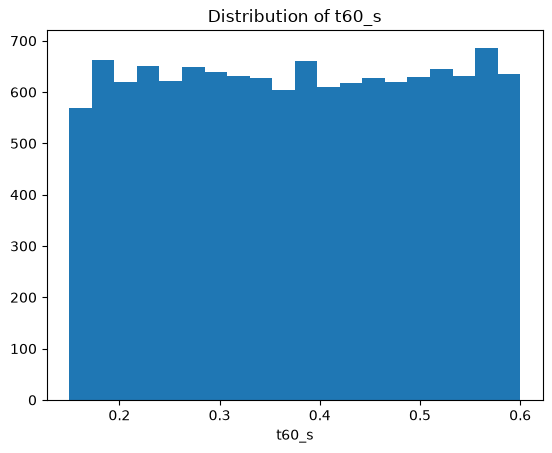

Number of trials with t60_s above 0.3s latency budget: 8441 (66.81%)


In [113]:
print(f"Distribution of t60_s")
plt.hist(present["t60_s"], bins=20)
plt.title(f"Distribution of t60_s")
plt.xlabel("t60_s")
plt.show()

num_t_above_latency_budget = (present["t60_s"] > 0.3).sum()
print(f"Number of trials with t60_s above 0.3s latency budget: {num_t_above_latency_budget} "
      f"({num_t_above_latency_budget / len(present) * 100:.2f}%)")

**IDEA:** That is not a bug in the data. If your reference is direct + early 50 ms, the model is being trained to suppress a tail extending up to 600 ms into the future - from a 300 ms window. Either the task is partly ill-posed, or the model learns a **statistical prior over rooms** rather than actually cancelling the tail it can't see.

In [114]:
# geometry invariants -- all recomputed from the coordinates that were recorded
df = D.df
lo, hi = D.cfg["source_distance_m"]

for speaker in ["target", "interferer"]:
    dist = np.sqrt((df[f"{speaker}_x"] - df["mic_x"])**2 + (df[f"{speaker}_y"] - df["mic_y"])**2)
    
    # clearance to the nearest of the four walls
    wall = pd.concat([df[f"{speaker}_x"], df["room_l"] - df[f"{speaker}_x"], df[f"{speaker}_y"], df["room_w"] - df[f"{speaker}_y"]], axis=1).min(axis=1)
    print(f"{speaker:11} distance {dist.min():.2f}..{dist.max():.2f} m "
        f"(config [{lo}, {hi}])   min wall clearance {wall.min():.2f} m (rule 0.3)")
        
    assert (dist >= lo - 0.01).all() and (dist <= hi + 0.01).all()
    assert (wall >= 0.3 - 1e-6).all() # I needed to put in the small fudge factor because the generator sometimes draws a source at exactly 0.3 m from a wall, and the float representation then fails the assert
    assert (df[f"{speaker}_z"] < df["room_h"]).all()

# T60 must be physically reachable in the room it was drawn for
vol = df["room_l"] * df["room_w"] * df["room_h"]
surf = 2 * (df["room_l"] * df["room_w"] + df["room_l"] * df["room_h"]
            + df["room_w"] * df["room_h"])
assert (df["t60_s"] >= 0.161 * vol / surf).all(), "T60 below the Sabine floor"

# the mic sits centrally by construction, never against a wall
print(f"mic at {(df['mic_x']/df['room_l']).min():.2f}.."
    f"{(df['mic_x']/df['room_l']).max():.2f} of room length (rule 0.35-0.65)")

print(f"\nT60 above the 0.3 s latency budget in {(df['t60_s'] > 0.3).mean():.0%} of trials")


target      distance 0.66..2.00 m (config [0.66, 2.0])   min wall clearance 0.31 m (rule 0.3)
interferer  distance 0.66..2.00 m (config [0.66, 2.0])   min wall clearance 0.30 m (rule 0.3)
mic at 0.35..0.65 of room length (rule 0.35-0.65)

T60 above the 0.3 s latency budget in 67% of trials


Distances come back at exactly 0.66..2.00 for both sources, and the mic sits at 0.35–0.65 of the room length. These confirm the recorded coordinates actually reproduce the sampling rules, rather than just trusting the generator. The finding that most matters is that the latency budget that we aim for of 200ms-300ms for target separation has 67% of the trials already exceding the budget. This requires a decision because we essentially have the following problem: the reference signal is the direct sound, which in its purest form after hitting the walls comes out to 50ms if it is a PURE signal and no reverb. Secondly, we have the budget to allow processing of this signal over 200-300ms, which means at BEST our model will only listen to 300ms of audio before being able to separate out the target speaker. However, we are sampling our T60, which is our parameter for controlling the amount of reverb, which can go all the way up to 600ms before all the sound has gotten to the speaker. So we essentially 300 more ms of signal contained within that audio stream that we are NOT allowed to see within that latency budget.

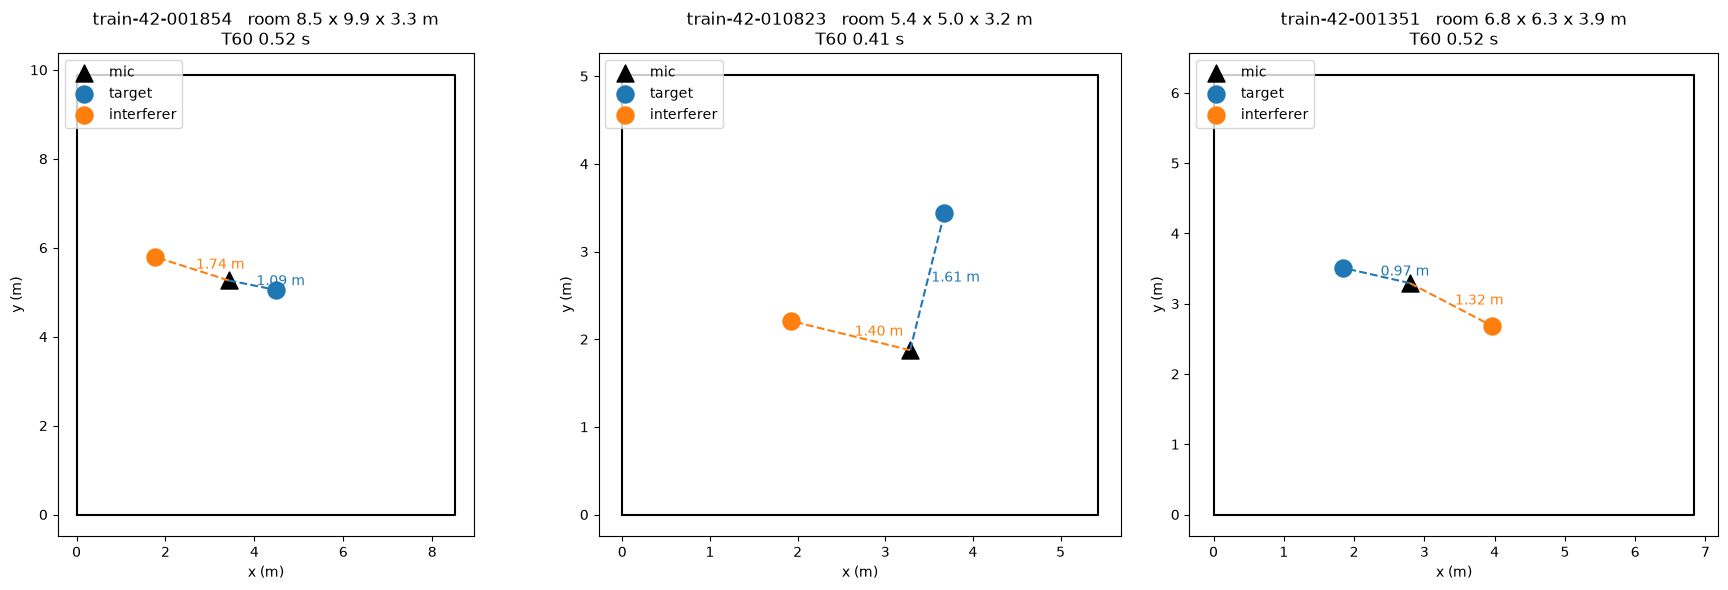

In [115]:
n_plots = len(random_indices)
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))

# Ensure axes is iterable in case there is only 1 index
if n_plots == 1:
    axes = [axes]

for ax, i in zip(axes, random_indices):
    row = D.df.iloc[i]

    # Draw room boundaries
    ax.plot([0, row["room_l"], row["room_l"], 0, 0],
            [0, 0, row["room_w"], row["room_w"], 0], color="black")
    
    # Plot entities
    ax.scatter(row["mic_x"], row["mic_y"], marker="^", s=150, color="black", label="mic")
    ax.scatter(row["target_x"], row["target_y"], s=150, color="tab:blue", label="target")
    ax.scatter(row["interferer_x"], row["interferer_y"], s=150, color="tab:orange", label="interferer")

    # Dashed lines to the mic, labelled with the distance
    for who, colour in [("target", "tab:blue"), ("interferer", "tab:orange")]:
        ax.plot([row["mic_x"], row[f"{who}_x"]], [row["mic_y"], row[f"{who}_y"]],
                color=colour, linestyle="--")
        
        d = ((row[f"{who}_x"] - row["mic_x"])**2 + (row[f"{who}_y"] - row["mic_y"])**2) ** 0.5
        
        ax.text((row["mic_x"] + row[f"{who}_x"]) / 2,
                (row["mic_y"] + row[f"{who}_y"]) / 2, f" {d:.2f} m", color=colour)

    # Apply axis-level formatting outside the inner loop
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    
    # Added a newline in the title so it doesn't overlap adjacent plots
    ax.set_title(f"{row['trial_id']}   room {row['room_l']:.1f} x {row['room_w']:.1f} x "
                 f"{row['room_h']:.1f} m\nT60 {row['t60_s']:.2f} s")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

We want to check that the activity level of both the interferer and the target can be roughly the same. This is so that our model doesnt just guess one over the other based on duration and not on voice qualities.

In [116]:
absent = D.df[D.df["target_absent"] == 1]
present = D.df[D.df["target_absent"] == 0]

cols = ["t60_s", "snr_db", "target_loudness_lufs", "mixture_length_s",
        "room_l", "room_w", "room_h", "interferer_activity", "interferer_speech_s"]
print(f"{'column':22} {'present':>9} {'absent':>9} {'gap/sd':>8}")
for col in cols:
    sd = D.df[col].std()
    gap = (absent[col].mean() - present[col].mean()) / sd
    print(f"{col:22} {present[col].mean():9.2f} {absent[col].mean():9.2f} {gap:+8.2f}")



column                   present    absent   gap/sd
t60_s                       0.38      0.38    +0.01
snr_db                     10.09     10.09    -0.00
target_loudness_lufs      -29.03    -28.96    +0.03
mixture_length_s           17.52     17.48    -0.03
room_l                      7.49      7.51    +0.01
room_w                      7.51      7.50    -0.01
room_h                      3.50      3.50    -0.01
interferer_activity         0.57      0.63    +0.40
interferer_speech_s         9.98     11.05    +0.37


Anything past about 1 sd is a giveaway worth chasing.

In [117]:
# 4.4  is T60 physically reachable, and did the rejection loop bend anything?
vol = D.df["room_l"] * D.df["room_w"] * D.df["room_h"]
surf = 2 * (D.df["room_l"] * D.df["room_w"] + D.df["room_l"] * D.df["room_h"] + D.df["room_w"] * D.df["room_h"])
# Sabine's equation, T60 = 0.161V / (S*alpha), at alpha = 1 -- the shortest T60
# this room could physically have, since a wall cannot absorb more than all the
# sound hitting it. Sabine (1922), "Collected Papers on Acoustics"; the same
# relation pra.inverse_sabine inverts in build_manifest.py. "Sabine floor" is
# our label for the alpha = 1 case, not a standard term.
sabine_floor = 0.161 * vol / surf

print(f"room volume {vol.min():.0f}..{vol.max():.0f} m3")
print(f"sabine floor on T60 {sabine_floor.min():.3f}..{sabine_floor.max():.3f} s")
print(f"config asks from {D.cfg['t60_s'][0]} s -- infeasible in the larger rooms")
print(f"trials below the floor: {(D.df['t60_s'] < sabine_floor).sum()} (must be 0)")

# the rejection loop could bias t60 towards small rooms. quartiles are a far better test of that than a correlation at this sample size.
lo, hi = D.cfg["t60_s"]
print(f"\nt60 quartiles  {np.percentile(D.df['t60_s'], [0,25,50,75,100]).round(3)}")
print(f"uniform gives  {np.percentile(np.linspace(lo,hi,10000), [0,25,50,75,100]).round(3)}")
print(f"corr(t60, volume) = {np.corrcoef(D.df['t60_s'], vol)[0,1]:+.3f}"
    f"   noise floor {2/np.sqrt(len(D.df)):.3f}")



room volume 77..395 m3
sabine floor on T60 0.111..0.178 s
config asks from 0.15 s -- infeasible in the larger rooms
trials below the floor: 0 (must be 0)

t60 quartiles  [0.15  0.264 0.377 0.491 0.6  ]
uniform gives  [0.15  0.262 0.375 0.488 0.6  ]
corr(t60, volume) = +0.005   noise floor 0.014


We want to check whether the T60 values were pushed towards small rooms due to the mathematical impossibilities of the low T60 in a large room. We want to check that our generator is NOT making these mistakes. We are making sure that we are redrawing our samples from an entirely new room instead of just resampling the T60 inside of a fixed room. The idea comes from my rejection sampler. My biggest room has a sabine floor score of 0.178. and some T60s are from 0.15s. So it is impossible to have such a low T60. We are just checking that 1. Our t60 and volume are not correlated as this would mean that we are pushing the t60 value away from uniform when rejection sampling, and 2. we are checking that the correlation just doesnt excede the noise floor, which is the highest we are willing to accept before the correlation becomes a statistically significant result.

In [118]:
#4.5  the configured distance is horizontal; the true 3-D distance differs
for who in ["target", "interferer"]:
    horiz = np.sqrt((D.df[f"{who}_x"] - D.df["mic_x"])**2 + (D.df[f"{who}_y"] - D.df["mic_y"])**2)
    true3d = np.sqrt(horiz**2 + (D.df[f"{who}_z"] - D.df["mic_z"])**2)
    print(f"{who:11} horizontal {horiz.min():.2f}..{horiz.max():.2f}, "  
        f"true 3-D {true3d.min():.2f}..{true3d.max():.2f}   "
        f"config {D.cfg['source_distance_m']}")

# in mono there is no spatial cue, so two speakers standing close is harmless
sep = np.sqrt((D.df["target_x"] - D.df["interferer_x"])**2 + (D.df["target_y"] - D.df["interferer_y"])**2)
print(f"speaker separation {sep.min():.2f}..{sep.max():.2f} m, "
    f"under 0.5 m in {(sep < 0.5).sum()} trials") 

target      horizontal 0.66..2.00, true 3-D 0.66..2.17   config [0.66, 2.0]
interferer  horizontal 0.66..2.00, true 3-D 0.66..2.18   config [0.66, 2.0]
speaker separation 0.01..3.94 m, under 0.5 m in 1259 trials


We use the above check to see the horizontal versus true 3-D distance of the target and interferer speakers relative to the microphone. The horizontal distance is calculated using the x and y coordinates, while the true 3-D distance also takes into account the z-coordinate (height) of the speakers and microphone. We can see that generally the speakers are actually in 3D space up to 4m away from each other in 3D space.

### 5. Enrollment and pairing
5.1 Enrollment criteria are combined to ensure that the only way to complete the task is by actually listening to the voice. The following variables act as a safe guard against finding features that the model can leverage that will prevent it from learning things that are not the voice of the target (and to prioritise it).

- `enrollment_utt`
- `enrollment_offset_s`
- `enrollment_length_s`
- `enrollment_eq`
- `target_speaker`
- `interferer_speaker`
- `target_chapter`
- `interferer_chapter`
- `same_gender`

In [119]:
# LibriSpeech metadata: which speaker is which sex, which chapter is which book
ls = ROOT / "data/librispeech/LibriSpeech"
sex, book = {}, {}
for line in (ls / "SPEAKERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    sex[f[0]] = f[1]
for line in (ls / "CHAPTERS.TXT").read_text(errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    book[f[0]] = f[5]

present = D.df[D.df["target_absent"] == 0]
target_book = present["target_chapter"].map(book)
enroll_chapter = present["enrollment_utt"].str.split("-").str[1]

print(f"target != interferer         "
    f"{(D.df['target_speaker'] != D.df['interferer_speaker']).all()}")
print(f"different books               "
    f"{(target_book != present['interferer_chapter'].map(book)).all()}")
print(f"enrollment chapter differs    {(enroll_chapter != present['target_chapter']).all()}")
print(f"enrollment BOOK differs       {(enroll_chapter.map(book) != target_book).all()}"
    f"   same book in {(enroll_chapter.map(book) == target_book).sum()} trials")

# same_gender must agree with the actual metadata, not just the intended rate
actual = (D.df["target_speaker"].map(sex) == D.df["interferer_speaker"].map(sex))
print(f"same_gender flag is truthful  {(D.df['same_gender'] == actual.astype(int)).all()}")

# the enrollment window must fit inside its clip
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
print(f"enrollment window fits        "
    f"{((D.df['enrollment_offset_s'] + D.df['enrollment_length_s']) <= edur + 1e-6).all()}")
print(f"enrollment clips all >= 5 s   {(edur >= D.df['enrollment_length_s']).all()}")


target != interferer         True
different books               True
enrollment chapter differs    True
enrollment BOOK differs       True   same book in 0 trials
same_gender flag is truthful  True
enrollment window fits        True
enrollment clips all >= 5 s   True


In [120]:
# is the enrollment offset uniform in the room available to it? We want to check if the enrollment offset is uniformly distributed within the available room of the enrollment clip. The available room is calculated as the duration of the enrollment utterance minus the length of the enrollment segment. We then compute the fraction of the enrollment offset relative to this available room and check its mean value. A uniform distribution would have a mean of 0.5.
edur = D.df["enrollment_utt"].map(D.utts["duration"].to_dict())
room = edur - D.df["enrollment_length_s"]

print(f"\noffset as fraction of available room: mean "
    f"{(D.df['enrollment_offset_s'] / room).mean():.3f} (uniform -> 0.500)")


offset as fraction of available room: mean 0.497 (uniform -> 0.500)


In [121]:
# speaker usage balance, target and interferer. We want to check if the generator is over-using a few speakers and under-using others.
print(f"target usage:     {D.df['target_speaker'].nunique()} distinct, "
    f"{D.df['target_speaker'].value_counts().min()}.."
    f"{D.df['target_speaker'].value_counts().max()} trials each")
print(f"interferer usage: {D.df['interferer_speaker'].nunique()} distinct, "
    f"{D.df['interferer_speaker'].value_counts().min()}.."
    f"{D.df['interferer_speaker'].value_counts().max()} trials each")


target usage:     1170 distinct, 1..52 trials each
interferer usage: 1172 distinct, 3..32 trials each


### 6. Noise

#### 6.1 Check that the noise bed level is within the configured range
- `noise_clip`
- `noise_offset_s`

In [122]:
# every clip named must exist in the index for this split's noise set
known = set(D.noise.index)
missing = set(D.df["noise_clip"]) - known
print(f"noise split '{D.cfg['noise_split']}': {len(known)} clips in the index")
print(f"clips named by the manifest but absent from that index: {len(missing)}\n")

#  no clip may be shared between a training and an evaluation manifest.               
train_clips = set(load("smoke_train").df["noise_clip"])
val_clips = set(load("smoke_val").df["noise_clip"])
print(f"clips shared between smoke_train and smoke_val: {len(train_clips & val_clips)}\n")

# is there enough noise left in the clip to cover the mixture?
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
remaining = clipdur - D.df["noise_offset_s"]
print(f"\nclip durations {clipdur.min():.1f}..{clipdur.max():.1f} s "
    f"(median {clipdur.median():.1f})")
print(f"mixtures       {D.df['mixture_length_s'].min():.1f}.."
    f"{D.df['mixture_length_s'].max():.1f} s")
print(f"trials needing more noise than the clip has left: "
    f"{(remaining < D.df['mixture_length_s']).sum()}/{len(D.df)}")
print(f"trials where the whole clip is shorter than the mixture: "
    f"{(clipdur < D.df['mixture_length_s']).sum()}/{len(D.df)}\n")

# how much of the library would survive a "long enough clips only" rule?
d = D.noise["duration"]
for t in [15.0, 20.0]:
    print(f"clips >= {t:4.1f} s: {(d >= t).sum():5} of {len(d)} ({(d >= t).mean():.2%})")


noise split 'tr': 20000 clips in the index
clips named by the manifest but absent from that index: 0

clips shared between smoke_train and smoke_val: 0


clip durations 3.4..47.6 s (median 10.0)
mixtures       15.0..20.0 s
trials needing more noise than the clip has left: 19510/19569
trials where the whole clip is shorter than the mixture: 19066/19569

clips >= 15.0 s:  1462 of 20000 (7.31%)
clips >= 20.0 s:    86 of 20000 (0.43%)


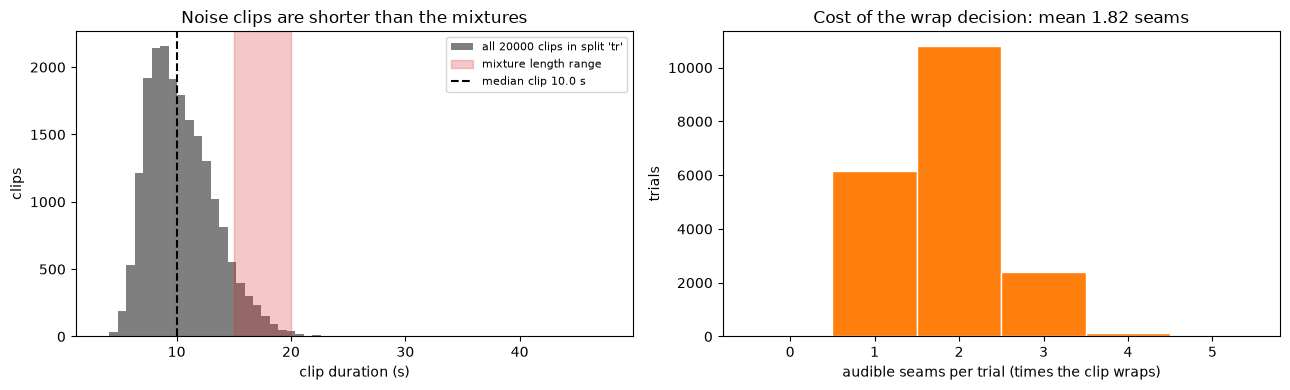

In [123]:
clipdur = D.df["noise_clip"].map(D.noise["duration"].to_dict())
# how many times the read pointer crosses the end of the clip
seams = np.floor((D.df["noise_offset_s"] + D.df["mixture_length_s"]) / clipdur)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.hist(D.noise["duration"], bins=60, color="tab:grey",
        label=f"all {len(D.noise)} clips in split '{D.cfg['noise_split']}'")
ax1.axvspan(D.df["mixture_length_s"].min(), D.df["mixture_length_s"].max(),
            color="tab:red", alpha=0.25, label="mixture length range")
ax1.axvline(D.noise["duration"].median(), color="black", linestyle="--",
            label=f"median clip {D.noise['duration'].median():.1f} s")
ax1.set_xlabel("clip duration (s)")
ax1.set_ylabel("clips")
ax1.set_title("Noise clips are shorter than the mixtures")
ax1.legend(fontsize=8)

ax2.hist(seams, bins=np.arange(-0.5, seams.max() + 1.5), color="tab:orange",
        edgecolor="white")
ax2.set_xlabel("audible seams per trial (times the clip wraps)")
ax2.set_ylabel("trials")
ax2.set_xticks(range(int(seams.max()) + 1))
ax2.set_title(f"Cost of the wrap decision: mean {seams.mean():.2f} seams")

plt.tight_layout()
plt.show()


### 7. Target-absent trials

The behaviour being trained here is *saying nothing*. A model trained only on trials where the target speaks learns "always emit a voice", because nothing in the loss ever rewards silence. Handed a mixture where the target never speaks, it does the only thing it knows and outputs the interferer. The judge transcribes the interferer's words, and by the metric every one of them is a hallucination — words attributed to a speaker who said nothing.

So `target_absent: 1` is a complete trial, not a missing row: a real enrolled speaker, a real interferer, a real room, and no target speech. CARTSE uses ~38% (Li & Seki, 2026); the configured 0.35 is in line with that.

Three things have to hold, and the third is the one that matters:

1. an absent row is internally consistent — the target fields are empty, everything else intact;
2. the achieved rate is the rate that was asked for;
3. **absence is not predictable from anything except the audio.** Any column that separates absent from present lets the model decide when to go quiet without ever consulting the enrollment.

#### 7.1  What an absent row keeps and what it drops

In [124]:
# --- 7.1  what an absent row still carries, and what it drops
absent = D.df[D.df["target_absent"] == 1]
present = D.df[D.df["target_absent"] == 0]
print(f"{D.split}: {len(absent)} absent, {len(present)} present\n")

print("dropped -- nothing to describe, so the field is empty")
for col in ["target_chapter", "target_utts", "target_onsets_s", "sir_db"]:
    print(f"  {col:22} null in {absent[col].isna().sum():5}/{len(absent)} absent, "
          f"{present[col].isna().sum():5}/{len(present)} present")




train: 6935 absent, 12634 present

dropped -- nothing to describe, so the field is empty
  target_chapter         null in  6935/6935 absent,     0/12634 present
  target_utts            null in  6935/6935 absent,     0/12634 present
  target_onsets_s        null in  6935/6935 absent,     0/12634 present
  sir_db                 null in  6935/6935 absent,     0/12634 present


We are checking in the above that the absent trials have null values for the target-related columns, as expected, We want the null score for each of the target-related columns in all absent trials.

In [125]:
print("\nzeroed -- a real measurement that happens to be zero")
for col in ["target_speech_s", "target_activity",
            "overlap_requested", "overlap_achieved"]:
    print(f"  {col:22} {absent[col].min():.1f}..{absent[col].max():.1f}")




zeroed -- a real measurement that happens to be zero
  target_speech_s        0.0..0.0
  target_activity        0.0..0.0
  overlap_requested      0.0..0.0
  overlap_achieved       0.0..0.0


The above is checking that we have float fields and values for the zeroed columns so that we do NOT have NaN values in the absent trials. 

In [126]:
print("\nkept -- an absent trial is a whole trial, not a truncated one")
print(f"  enrollment speaker is the target  "
      f"{(absent['enrollment_utt'].str.split('-').str[0] == absent['target_speaker']).all()}")
print(f"  enrollment is never the interferer "
      f"{not (absent['enrollment_utt'].str.split('-').str[0] == absent['interferer_speaker']).any()}")
print(f"  distinct enrollment clips         {absent['enrollment_utt'].nunique()}/{len(absent)}")
print(f"  the target still has a position   "
      f"{absent[['target_x', 'target_y', 'target_z']].notna().all().all()}")


kept -- an absent trial is a whole trial, not a truncated one
  enrollment speaker is the target  True
  enrollment is never the interferer True
  distinct enrollment clips         6752/6935
  the target still has a position   True


The above check is used to confirm that even when the target is absent, the enrollment speaker is still the target, and the interferer is never the enrollment speaker. 

In [127]:
# sampled, then unused: there is no target signal to normalise to this loudness.
# The renderer must not silently apply it to the interferer instead.
print(f"\n  target_loudness_lufs is still drawn: "
      f"{absent['target_loudness_lufs'].min():.1f}.."
      f"{absent['target_loudness_lufs'].max():.1f} LUFS -- dead on these rows")


  target_loudness_lufs is still drawn: -33.0..-25.0 LUFS -- dead on these rows


The above check shows that the generator is still generating target loudness values even for absent trials, which is not really a problem but something to take note of. We must just make sure that we are using the intereferer as the reference point.

`target_loudness_lufs` is drawn on absent rows but has nothing to normalise. Harmless in the manifest, a trap in the renderer: applying it to the interferer instead would make absent mixtures a fixed loudness and hand the model the answer. The renderer must ignore it when `target_absent` is 1.

#### 7.2  Does the achieved rate match the configured rate?

In [128]:
# did the requested absent fraction survive the generator?
def intended_absent(trial_id, fraction):
    digest = hashlib.blake2b(trial_id.encode(), digest_size=8).digest()
    seeds = np.random.SeedSequence(int.from_bytes(digest, "big")).spawn(4)
    return float(np.random.default_rng(seeds[3]).random()) < fraction


for split in ["train", "val", "smoke_train", "smoke_val"]:
    S = load(split)
    frac = S.cfg["target_absent_fraction"]
    kept = S.df["trial_id"].map(lambda t: intended_absent(t, frac)).astype(int)
    assert (kept == S.df["target_absent"]).all(), f"{split}: replay disagrees"

    failed_file = S.path.with_suffix(".failed.txt")
    dropped = failed_file.read_text().split() if failed_file.exists() else []
    dropped_absent = sum(intended_absent(t, frac) for t in dropped)
    rate = (S.df["target_absent"] == 1).mean()

    print(f"{split:12} asked {frac:.2f}  got {rate:.3f}  ({len(S.df)} trials)")
    print(f"{'':12} dropped {len(dropped):4}:  {dropped_absent} absent, "
          f"{len(dropped) - dropped_absent} present")


train        asked 0.35  got 0.354  (19569 trials)
             dropped  431:  0 absent, 431 present
val          asked 0.35  got 0.382  (199 trials)
             dropped    1:  0 absent, 1 present
smoke_train  asked 0.35  got 0.280  (50 trials)
             dropped    0:  0 absent, 0 present
smoke_val    asked 0.35  got 0.700  (20 trials)
             dropped    0:  0 absent, 0 present


The above is validating that we have the correct number of absent trials in the datasets. These values indicate that we have slighlty more absent trials than expected in train and val but it is neglible and something to report in my paper.

#### 7.3  Can absence be predicted without listening for the target?

In [129]:
# can absence be predicted without listening for the target?
# AUC of a one-column classifier: 0.5 is "this column says nothing", 1.0 is
# "this column gives the answer away". Written out rather than imported so the
# notebook keeps no dependency beyond numpy -- it is the Mann-Whitney identity.
def auc(y, score):
    ok = pd.notna(score)
    y, score = np.asarray(y)[ok], pd.Series(score)[ok].rank().to_numpy()
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    return (score[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


y = (D.df["target_absent"] == 1).astype(int)
cols = ["interferer_activity", "interferer_speech_s", "mixture_length_s",
        "snr_db", "target_loudness_lufs", "t60_s", "room_l", "room_h",
        "enrollment_offset_s", "noise_offset_s", "same_gender", "enrollment_eq"]

print(f"base rate {y.mean():.3f}   ({len(D.df)} trials)\n")
print(f"{'column':24} {'present':>9} {'absent':>9} {'gap/sd':>8} {'AUC':>7}")
for col in sorted(cols, key=lambda c: -abs(auc(y, D.df[c]) - 0.5)):
    sd = D.df[col].std()
    gap = (absent[col].mean() - present[col].mean()) / sd if sd else 0.0
    print(f"{col:24} {present[col].mean():9.3f} {absent[col].mean():9.3f} "
          f"{gap:+8.2f} {auc(y, D.df[col]):7.3f}")


base rate 0.354   (19569 trials)

column                     present    absent   gap/sd     AUC
interferer_activity          0.569     0.633    +0.40   0.614
interferer_speech_s          9.977    11.053    +0.37   0.607
mixture_length_s            17.521    17.476    -0.03   0.491
target_loudness_lufs       -29.032   -28.964    +0.03   0.509
noise_offset_s               5.187     5.250    +0.02   0.505
room_l                       7.491     7.512    +0.01   0.504
same_gender                  0.498     0.491    -0.01   0.496
room_h                       3.498     3.495    -0.01   0.497
t60_s                        0.376     0.377    +0.01   0.502
enrollment_eq                0.500     0.501    +0.00   0.501
enrollment_offset_s          4.119     4.107    -0.00   0.500
snr_db                      10.094    10.087    -0.00   0.500


Ten of the twelve columns sit on AUC 0.50 which means they say nothing, which is what is wanted. `interferer_activity` does not: **AUC 0.614, +0.40 sd.**

AUC 0.614 is weak, a model betting on it alone is right 61% of the time on a ranking task, but it is a free 11 points above chance that requires no listening. 
I am happy with this result as we will not be plugging these values directly into the model, but to build the audio. It is just useful to know whether these variables could confound the audio generation.

#### 7.4  The enrollment voice is the real leak

We need the check below for the following reasons:  If we do not have a good mixture of target speakers and absent trials, then our model could learn that only certain speakers are ever present, and other speakers always absent. We want to ensure that our model does not learn the unique voices to predict the what audio to output, but rather to SEPARATE the voice from the output. Big difference. 

In [130]:
# the enrollment voice itself is a cue
# Score each trial by how often its target speaker is absent in the OTHER trials.
def speaker_prior(df, col="target_speaker"):
    g = df.groupby(col)["target_absent"]
    return ((g.transform("sum") - df["target_absent"])
            / (g.transform("size") - 1).replace(0, np.nan))


for split in ["train", "val"]:
    S = load(split)
    ys = (S.df["target_absent"] == 1).astype(int)
    print(f"{split:6}  AUC from target speaker {auc(ys, speaker_prior(S.df)):.3f}"
          f"   from interferer speaker "
          f"{auc(ys, speaker_prior(S.df, 'interferer_speaker')):.3f}")

# why: the absent branch skips pick_run entirely, so it never needs a second book. But the present branch does, so it is possible to have a target speaker with only one book, and that speaker can never be a present target. 
book = {}
for line in (ROOT / "data/librispeech/LibriSpeech/CHAPTERS.TXT").read_text(
        errors="replace").splitlines():
    if line.lstrip().startswith(";") or not line.strip():
        continue
    f = [p.strip() for p in line.split("|")]
    book[f[0]] = f[5]

books = D.utts.groupby("speaker")["chapter"].apply(lambda c: c.map(book).nunique())
ever_present = set(present["target_speaker"])
multi = set(books[books >= 2].index.astype(str))

print(f"\nspeakers in this split's index         {len(books)}")
print(f"  with 2+ books (a present target is possible) {len(multi)}")
print(f"  that ever ARE a present target               {len(ever_present)}")
print(f"  the two sets are the same speakers           {multi == ever_present}")

usage = D.df.groupby("target_speaker")["target_absent"].agg(["mean", "size"])
print(f"\nspeakers used as a target              {len(usage)}")
print(f"  absent in every trial they appear in {(usage['mean'] == 1).sum()}"
      f"  = {D.df['target_speaker'].isin(usage[usage['mean'] == 1].index).mean():.1%}"
      f" of trials")
print(f"  trials each, one-book vs multi-book: "
      f"{usage.loc[~usage.index.isin(multi), 'size'].mean():.1f} vs "
      f"{usage.loc[usage.index.isin(multi), 'size'].mean():.1f}")


train   AUC from target speaker 0.795   from interferer speaker 0.502
val     AUC from target speaker 0.756   from interferer speaker 0.555

speakers in this split's index         1172
  with 2+ books (a present target is possible) 467
  that ever ARE a present target               467
  the two sets are the same speakers           True

speakers used as a target              1170
  absent in every trial they appear in 703  = 21.3% of trials
  trials each, one-book vs multi-book: 5.9 vs 33.0


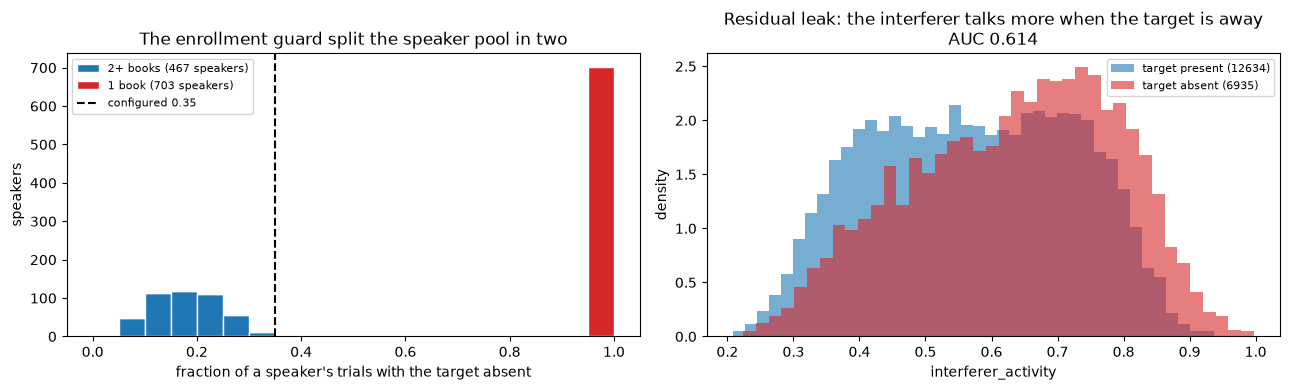

In [131]:
one_book = usage[~usage.index.isin(multi)]["mean"]
two_book = usage[usage.index.isin(multi)]["mean"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bins = np.linspace(0, 1, 21)
ax1.hist([two_book, one_book], bins=bins, stacked=True, edgecolor="white", color=["tab:blue", "tab:red"], label=[f"2+ books ({len(two_book)} speakers)",
                                                                                                                  f"1 book ({len(one_book)} speakers)"])
ax1.axvline(D.cfg["target_absent_fraction"], color="black", linestyle="--", label=f"configured {D.cfg['target_absent_fraction']}")
ax1.set_xlabel("fraction of a speaker's trials with the target absent")
ax1.set_ylabel("speakers")
ax1.set_title("The enrollment guard split the speaker pool in two")
ax1.legend(fontsize=8)

ax2.hist(present["interferer_activity"], bins=40, alpha=0.6, density=True,  color="tab:blue", label=f"target present ({len(present)})")
ax2.hist(absent["interferer_activity"], bins=40, alpha=0.6, density=True,
         color="tab:red", label=f"target absent ({len(absent)})")
ax2.set_xlabel("interferer_activity")
ax2.set_ylabel("density")
ax2.set_title(f"Residual leak: the interferer talks more when the target is away\nAUC {auc(y, D.df['interferer_activity']):.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


**AUC 0.795 from the identity of the enrolled speaker alone.** No part of the mixture is consulted to compute that number. The interferer's identity says nothing (0.502), so this is specifically about the voice the model is told to listen for.

The cause is exact, not statistical. The present branch needs the target to own a second book, because the enrollment must come from a different book (`decisions.md` 2026-08-11). The absent branch skips `pick_run` and needs no such thing. When the retry loop draws a one-book speaker it silently redraws — so **the 467 speakers with two or more books are precisely the 467 that ever appear as a present target**, and the other 703 appear only in absent trials, 21.3% of the split. The left panel shows two disjoint populations with nothing between them.

The 2026-08-11 entry asked for exactly this check, and predicted single-book speakers would "yield no valid present trial". What actually happened is worse than dropping out: they were reassigned to absent-only, at 5.9 trials each against 33.0 for the two-book speakers, which turned a coverage cost into a label leak.

Why it matters for training rather than for reporting: the eval splits are speaker-disjoint and carry no absent trials, so no reported number is contaminated. But 35% of every training batch can have its silence decision made by voice recognition instead of by listening, and the push-to-silence term — the one thing absent trials exist to teach — is the term that stops being trained.

Cheapest fix, and the one recommended in `decisions-pending.md` B9: **draw the target speaker for absent trials from the two-book pool as well.** It costs nothing in realism, since the enrollment guard is about content leakage and an absent trial has no target content to leak. It leaves `interferer_activity` at 0.614, which is a separate and much smaller problem.

### 8. Final variables check:
Considering the following variables: 
- `enrollment_eq` - is used to simulate a DIFFERENT enrollement device and borrowed as an idea from CARTSE
- `same_gender`

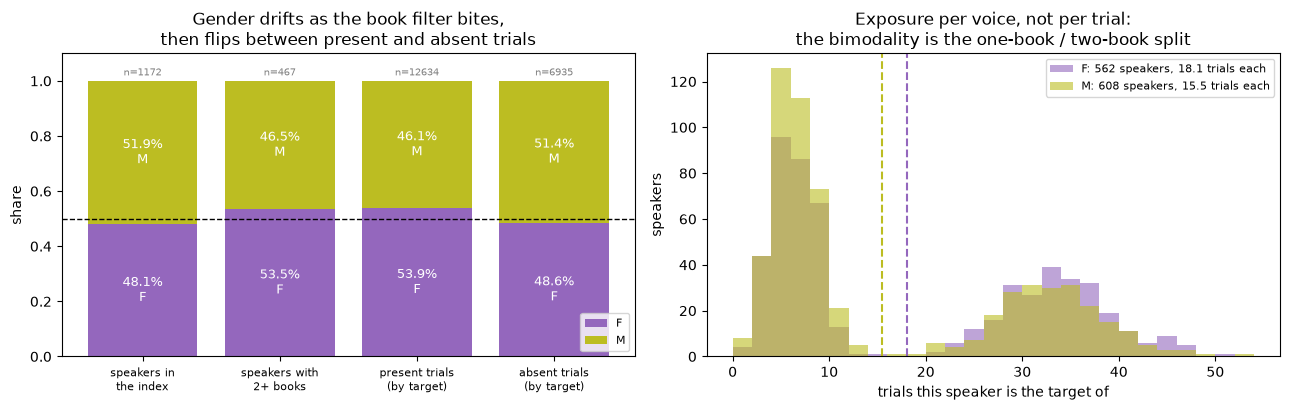

In [139]:

pool = pd.Series({s: sex[s] for s in D.utts["speaker"].unique().astype(str)})
books = D.utts.groupby("speaker")["chapter"].apply(lambda c:
c.map(book).nunique())
multi = set(books[books >= 2].index.astype(str))

stages = [
    ("speakers in\nthe index",      pool),
    ("speakers with\n2+ books",     pool[pool.index.isin(multi)]),
    ("present trials\n(by target)", present["target_speaker"].map(sex)),
    ("absent trials\n(by target)",  absent["target_speaker"].map(sex)),
]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
xs = np.arange(len(stages))
fshare = [(s == "F").mean() for _, s in stages]
ax1.bar(xs, fshare, color="tab:purple", label="F")
ax1.bar(xs, [1 - f for f in fshare], bottom=fshare, color="tab:olive", label="M")
ax1.axhline(0.5, color="black", linestyle="--", linewidth=1)
for x, f, (lab, s) in zip(xs, fshare, stages):
    ax1.text(x, f / 2, f"{f:.1%}\nF", ha="center", va="center", color="white", fontsize=9)
    ax1.text(x, f + (1 - f) / 2, f"{1-f:.1%}\nM", ha="center", va="center", color="white", fontsize=9)
    ax1.text(x, 1.02, f"n={len(s)}", ha="center", fontsize=7, color="grey")
ax1.set_xticks(xs); ax1.set_xticklabels([l for l, _ in stages], fontsize=8)
ax1.set_ylim(0, 1.10); ax1.set_ylabel("share")
ax1.set_title("Gender drifts as the book filter bites,\n"
            "then flips between present and absent trials")
ax1.legend(fontsize=8, loc="lower right")


# not "is it 50/50" but "does the model see each voice equally often"
usage = D.df.groupby("target_speaker").size()
gender = pd.Series({s: sex[s] for s in usage.index})
bins = np.arange(0, usage.max() + 3, 2)
for g, colour in [("F", "tab:purple"), ("M", "tab:olive")]:
    v = usage[gender == g]
    ax2.hist(v, bins=bins, alpha=0.6, color=colour,
            label=f"{g}: {len(v)} speakers, {v.mean():.1f} trials each")
    ax2.axvline(v.mean(), color=colour, linestyle="--")
ax2.set_xlabel("trials this speaker is the target of")
ax2.set_ylabel("speakers")
ax2.set_title("Exposure per voice, not per trial:\n"
            "the bimodality is the one-book / two-book split")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Final healthchecks

In [132]:
def check(D):
    df = D.df
    present = df[df["target_absent"] == 0]

    fails = []

    def ok(name, passed, detail=""):
        print(f"  {'PASS' if passed else 'FAIL'}  {name}   {detail}")
        if not passed:
            fails.append(name)

    print(f"{D.split}: {len(df)} trials, {len(present)} with the target present")

    ok("trial_ids unique", df["trial_id"].is_unique)
    ok("target never equals interferer",
        (df["target_speaker"] != df["interferer_speaker"]).all())
    ok("sir_db null exactly when target absent",
        (df["sir_db"].isna() == (df["target_absent"] == 1)).all())
    ok("enrollment speaker is the target",
        (df["enrollment_utt"].str.split("-").str[0] == df["target_speaker"]).all())
    ok("enrollment chapter differs from mixture chapter",
        (present["enrollment_utt"].str.split("-").str[1] != present["target_chapter"]).all())

    # every sampled column inside the range the config asked for
    for col, key in RANGES.items():
        lo, hi = D.cfg[key]
        v = df[col][df["target_absent"] == 0] if col == "overlap_requested" else df[col]
        v = v.dropna()
        ok(f"{col} within [{lo}, {hi}]", ((v >= lo - 1e-6) & (v <= hi + 1e-6)).all(),
            f"observed {v.min():.3f}..{v.max():.3f}, covers {(v.max()-v.min())/(hi-lo):.0%}")

    # derived columns must agree with what produced them
    d = (present["target_activity"]
        - present["target_speech_s"] / present["mixture_length_s"]).abs()
    ok("activity == speech_s / length", d.max() < 1e-3, f"worst {d.max():.1e}")
    d = (present["target_speech_s"] - present["target_dur_list"].map(sum)).abs()
    ok("speech_s == sum(durations)", d.max() < 1e-3, f"worst {d.max():.1e}")

    worst_ov, worst_end = 0.0, -9.9
    for _, row in df.iterrows():
        shared = 0.0
        for t_start, t_end in spans(row, "target"):
            for i_start, i_end in spans(row, "interferer"):
                shared += max(0.0, min(t_end, i_end) - max(t_start, i_start))

        worst_ov = max(worst_ov, abs(shared / row["mixture_length_s"]
                                    - row["overlap_achieved"]))
        ends = [e for who in ("target", "interferer") for _, e in spans(row, who)]
        worst_end = max(worst_end, max(ends) - row["mixture_length_s"])
    ok("overlap_achieved recomputes", worst_ov < 1e-3, f"worst {worst_ov:.1e}")

    miss = (present["overlap_achieved"] - present["overlap_requested"]).abs()
    ok("overlap miss within tolerance", miss.max() <= D.cfg["overlap_tolerance"] + 1e-9,
        f"worst {miss.max():.4f} of {D.cfg['overlap_tolerance']}")
    # 1 ms, not 1 us -- see the note below
    ok("no source runs past the window", worst_end < 1e-3,
        f"worst overshoot {worst_end*1000:+.3f} ms")

    lo, hi = D.cfg["source_distance_m"]
    for who in ("target", "interferer"):
        dist = np.sqrt((df[f"{who}_x"] - df["mic_x"])**2
                        + (df[f"{who}_y"] - df["mic_y"])**2)
        wall = pd.concat([df[f"{who}_x"], df["room_l"] - df[f"{who}_x"],
                        df[f"{who}_y"], df["room_w"] - df[f"{who}_y"]],
                        axis=1).min(axis=1)
        ok(f"{who} distance in [{lo}, {hi}]",
            ((dist >= lo - 0.01) & (dist <= hi + 0.01)).all(),
            f"{dist.min():.2f}..{dist.max():.2f}")
        ok(f"{who} clears every wall by 0.3 m", (wall >= 0.3).all(), f"min {wall.min():.2f}")
        ok(f"{who} below the ceiling", (df[f"{who}_z"] < df["room_h"]).all())

    vol = df["room_l"] * df["room_w"] * df["room_h"]
    surf = 2 * (df["room_l"]*df["room_w"] + df["room_l"]*df["room_h"]
                + df["room_w"]*df["room_h"])
    ok("t60 reachable in its room (Sabine)", (df["t60_s"] >= 0.161 * vol / surf).all())

    print("\n  warnings (true of the data, not yet decided in the design)")
    print(f"    no T60 reserve: t60 reaches {df['t60_s'].max():.2f} s and the last "
        f"source ends {-worst_end*1000:.0f} ms before the window closes")
    print(f"    absent fraction {(df['target_absent']==1).mean():.2f} vs configured "
        f"{D.cfg['target_absent_fraction']}")
    print(f"\n  {len(fails)} failed" if fails else "\n  all checks passed")
    return fails


check(load("smoke_train"))
check(load("smoke_val"))


smoke_train: 50 trials, 36 with the target present
  PASS  trial_ids unique   
  PASS  target never equals interferer   
  PASS  sir_db null exactly when target absent   
  PASS  enrollment speaker is the target   
  PASS  enrollment chapter differs from mixture chapter   
  PASS  mixture_length_s within [15.0, 20.0]   observed 15.011..19.953, covers 99%
  PASS  overlap_requested within [0.2, 0.7]   observed 0.223..0.685, covers 92%
  PASS  sir_db within [-5.0, 15.0]   observed -4.710..14.530, covers 96%
  PASS  snr_db within [0.0, 20.0]   observed 1.530..19.920, covers 92%
  PASS  target_loudness_lufs within [-33.0, -25.0]   observed -32.480..-25.160, covers 91%
  PASS  t60_s within [0.15, 0.6]   observed 0.151..0.595, covers 99%
  PASS  room_l within [5.0, 10.0]   observed 5.064..9.868, covers 96%
  PASS  room_w within [5.0, 10.0]   observed 5.013..9.802, covers 96%
  PASS  room_h within [3.0, 4.0]   observed 3.069..3.992, covers 92%
  PASS  mic_z within [0.9, 1.8]   observed 0.903..

[]